# Predicting heart disease using Machine Learning

This notebook looks into using various Python-based machine learning and data science libraries in an attempt to build a machine learning model capable of predicting wether or not someone has heart disease based on their medical attributes.

My steps to follow:
1. Problem definition
2. Data 
3. Evaluation
4. Features 
5. Modelling
6. Experimentation

## 1. Problem Definition
> Given inforamation about physiological and physical variables related with a patient (e.g. age, weight, cholesterol, etc.), Is is possible to predict wether the patient has heart disease or not?

## 2. Data 
The dataset used for this analysis and problem can be obtained for UCI Machine Learning Repository --> https://archive.ics.uci.edu/dataset/45/heart+disease

Also the data can be downloaded from the Kaggle website --> https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data

In both of them we can find some explanations, detailed information and papers that have used this dataset for research. 

## 3. Evalutation
> We are aiming to reach at least 95% of accuracy in predicting heart disease. In the Medicine field, the Proof of Concept must achieve these high values of precision and accuracy in order to continue with the next stage.

## 4. Features 

**Feature variables information** 

| Variable Name | Role | Type | Demographic	| Description | Units | Missing Values |
| ------------- | ---- | ---- | ----------- | ----------- | ----- | -------------- |
|age | Feature | Integer | Age | | | years | no |
|sex | Feature | Categorical | Sex | | | no | 
|cp | Feature | Categorical | | | | no | 
|trestbps | Feature | Integer | | | resting blood pressure (on admission to the hospital) | mm Hg | no |
|chol | Feature	| Integer | | | serum cholestoral | mg/dl | no | 
|fbs | Feature | Categorical | | fasting blood sugar > 120 |  mg/dl | no | 
|restecg | Feature | Categorical| 	|	|  | no |
|thalach | Feature | Integer |  | maximum heart rate achieved|  | no |
|exang | Feature | Categorical | | exercise induced angina |   | no |
|oldpeak | Feature | Integer | | ST depression induced by exercise relative to rest | |	no |
|slope | Feature | Categorical | | | | no |
|ca | Feature| Integer | | number of major vessels (0-3) colored by flourosopy |	| yes | 
|thal| Feature | Categorical | | | | yes |
|num | Target | Integer | | diagnosis of heart disease | | no |


## Our Tools
Let's import the tool we need to start with our machine learning project

In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Models from Scikit-Learn 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

## Load data

In [2]:
df = pd.read_csv('heart-disease.csv')
display(df)

print(f"The shape of our data is {df.shape}")

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


The shape of our data is (303, 14)


## Exploratory Data Analysis

First, I want to get familiar with the data as much as possible. Having a deep insight into the dataset will help me to employ the best machine learning model for the our problem. 

What we are looking now is to answer this questions:
1. What question(s) are you trying to solve?
2. What kind of data do we have and how do we treat the different types of data?
3. What's missing from the data and how do you deal with?
4. Where are the outliers and why should you care about them?
5. How can you add, change or remove features to get more out of your data?

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
# Count positives and negatives cases
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

We have a **balanced number** of positive and negative results. 

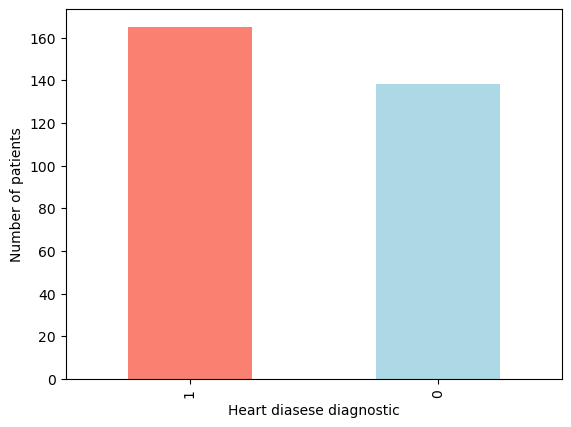

In [5]:
df['target'].value_counts().plot(kind='bar', color = ['salmon', 'lightblue'], xlabel='Heart diasese diagnostic',
                                 ylabel = 'Number of patients');

In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
# is there any missing value?
df.isna().count()

age         303
sex         303
cp          303
trestbps    303
chol        303
fbs         303
restecg     303
thalach     303
exang       303
oldpeak     303
slope       303
ca          303
thal        303
target      303
dtype: int64

### Observe any correation with sex and heart disease

In [8]:
df['sex'].value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [9]:
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,24,114
1,72,93


([<matplotlib.axis.XTick at 0x255f456f850>,
 [Text(0, 0, 'Negative'), Text(1, 0, 'Positive')])

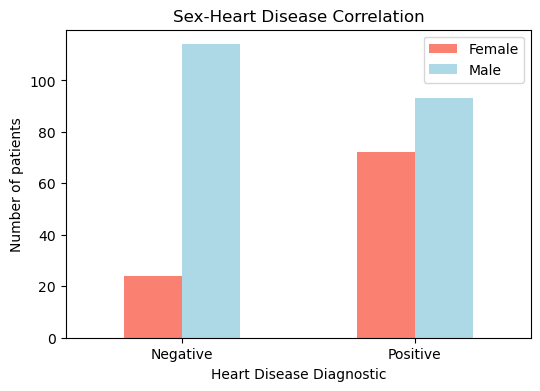

In [10]:
pd.crosstab(df.target, df.sex).plot(kind='bar', color = ['Salmon', 'Lightblue'], figsize=(6,4))
plt.title('Sex-Heart Disease Correlation')
plt.legend(['Female', 'Male'])
plt.ylabel('Number of patients')
plt.xlabel('Heart Disease Diagnostic')
plt.xticks([0,1], labels=['Negative', 'Positive'], rotation = 0)

### Look at "thalach" (maximum heart rate measured) vs Age

Text(0.5, 0, "Patient's age (years)")

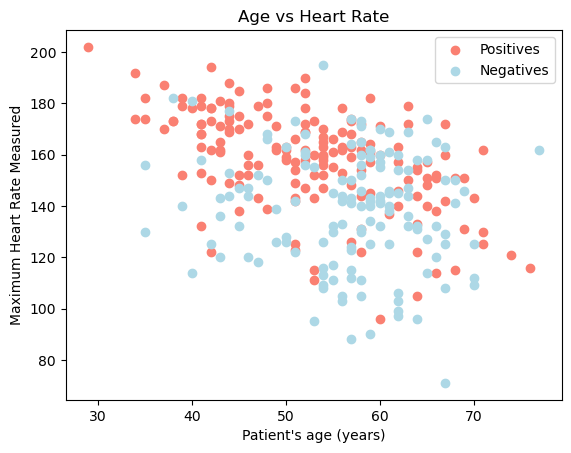

In [11]:
# Patient's age for positive and negative cases
age_p = df['age'][df.target == 1]
age_n = df['age'][df.target == 0]

# Heart rate for + & - cases
hr_p = df['thalach'][df.target == 1]
hr_n = df['thalach'][df.target == 0]

plt.scatter(age_p, hr_p, color= 'Salmon')
plt.scatter(age_n, hr_n, color= 'Lightblue')

plt.legend(['Positives', 'Negatives'])
plt.title('Age vs Heart Rate')
plt.ylabel('Maximum Heart Rate Measured')
plt.xlabel('Patient\'s age (years)')

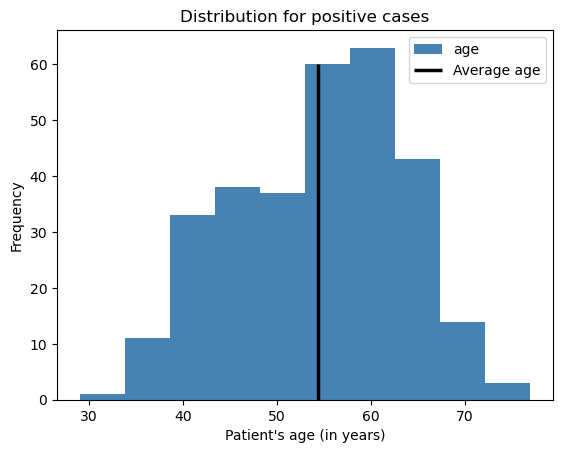

In [12]:
df.age.plot.hist(color= 'steelblue')
plt.xlabel('Patient\'s age (in years)')
plt.title('Distribution for positive cases')
plt.vlines(x = df.age.mean(), 
           ymin = 0,
           ymax = 60,
           colors= 'black',
           label = 'Average age',
           linewidth = 2.5)
plt.legend()

### Chest pain as a predictor for heart disease

**Chest pain type:**
* 1: typical angina
* 2: atypical angina
* 3: non-anginal pain
* 4: asymptomatic

In [13]:
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


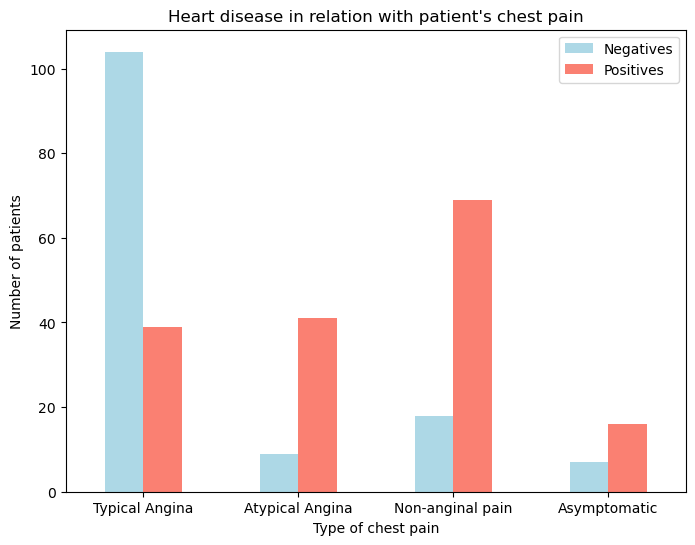

In [14]:
# More visual
pd.crosstab(df.cp, df.target).plot(kind= 'bar', figsize= (8,6), color= ['Lightblue', 'Salmon'])

plt.title('Heart disease in relation with patient\'s chest pain')
plt.ylabel('Number of patients')
plt.xlabel('Type of chest pain')
plt.legend(['Negatives' ,'Positives'])
plt.xticks([0,1,2,3], labels=['Typical Angina', 'Atypical Angina', 'Non-anginal pain', 'Asymptomatic'], 
           rotation=0);

### Correlation Matrix

Now we would like to explore the correlation betweeen the independent variables. 

In [15]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


Let's make it more visulal

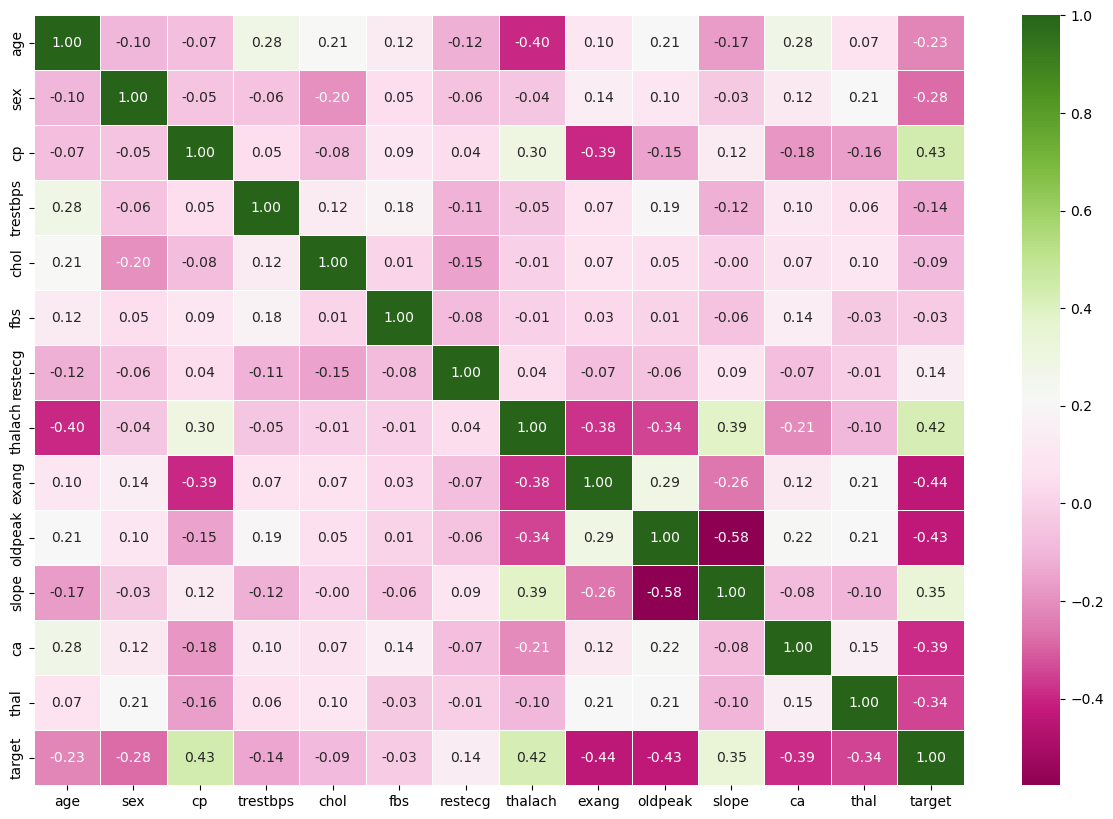

In [16]:
correlation_matrix = df.corr()
fig, ax = plt.subplots(figsize=(15,10))
ax = sns.heatmap(correlation_matrix,
                 annot= True,
                 linewidths= 0.5, 
                 fmt= '.2f', 
                 cmap = "PiYG")

## 5. Modelling

In [17]:
# Split our dataset in feature matrix and target variable

X = df.drop('target', axis = 1) # Feature Matrix
y = df['target']

print('The feature matrix is \n')
display(X)
print('\n Our target variable is')
display(y)

The feature matrix is 



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3



 Our target variable is


0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [18]:
# Initize random seed
np.random.seed(28)

# Data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [19]:
print('Train Data')
display(X_train,y_train)

Train Data


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
114,55,1,1,130,262,0,1,155,0,0.0,2,0,2
222,65,1,3,138,282,1,0,174,0,1.4,1,1,2
194,60,1,2,140,185,0,0,155,0,3.0,1,0,2
214,56,1,0,125,249,1,0,144,1,1.2,1,1,2
51,66,1,0,120,302,0,0,151,0,0.4,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,38,1,3,120,231,0,1,182,1,3.8,1,0,3
32,44,1,1,130,219,0,0,188,0,0.0,2,0,2
278,58,0,1,136,319,1,0,152,0,0.0,2,2,2
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1


114    1
222    0
194    0
214    0
51     1
      ..
259    0
32     1
278    0
5      1
257    0
Name: target, Length: 242, dtype: int64

In [20]:
print('Test Data')
display(X_test, y_test)

Test Data


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
86,68,1,2,118,277,0,1,151,0,1.0,2,1,3
33,54,1,2,125,273,0,0,152,0,0.5,0,1,2
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
155,58,0,0,130,197,0,1,131,0,0.6,1,0,2
203,68,1,2,180,274,1,0,150,1,1.6,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,54,1,0,124,266,0,0,109,1,2.2,1,1,3
238,77,1,0,125,304,0,0,162,1,0.0,2,3,2
248,54,1,1,192,283,0,0,195,0,0.0,2,1,3
58,34,1,3,118,182,0,0,174,0,0.0,2,0,2


86     1
33     1
228    0
155    1
203    0
      ..
187    0
238    0
248    0
58     1
207    0
Name: target, Length: 61, dtype: int64

Several ML models will be used for training the data. After this, the ML performance will be tested to assess the ML model's accuracy. Remember, the aim for this value must be at least 95% in order to continue with the next step.

We have taken a look to the scikit-learn's **Machine Learning Map** (https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html) to have a guidance on which models to apply for certain cases. I added *Logistic Regression* (which is used for classification problems) in the mix to compare the performaces between these three models:
1. Logistic Regression
2. K-Nearest Neighbors Classifier
3. Random Forest Classifier

In [32]:
# Model's dictionary
models = {'Logistic Regression': LogisticRegression(max_iter=1000),
          'KNN': KNeighborsClassifier(), 
          'Random Forest': RandomForestClassifier()}

# We will define a function that apply the three models to fit and evaluate the score of each model
def fit_and_score(models, X_train, X_test, y_train, y_test):
    '''
    Fit and evaluate the different models
    '''
    # random seed
    np.random.seed(28)
    
    # Dictionary for keeping the model's scores
    model_scores = {}
    
    # loop to evaluate all the model list
    for name, model in models.items():
        # fit data on model
        model.fit(X_train, y_train)
        # Evaluate the different ML model scores and storing the values into the dictionary
        model_scores[name] = model.score(X_test, y_test)
    return model_scores

In [33]:
# Lets evaluate the models with their default hyperparameters
model_scores = fit_and_score(models= models,
                             X_train= X_train, 
                             X_test= X_test, 
                             y_train = y_train, 
                             y_test = y_test)

print(f'The ML models\' scores are \n: {model_scores}')

The ML models' scores are 
: {'Logistic Regression': 0.8524590163934426, 'KNN': 0.6229508196721312, 'Random Forest': 0.819672131147541}


### Model Comparison

Text(0.5, 1.0, "Models' Accuracy")

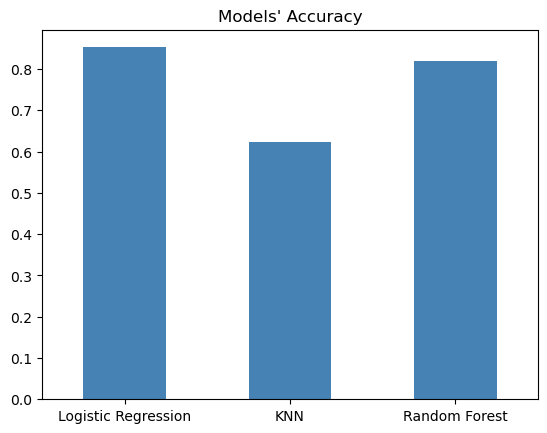

In [34]:
model_comparison = pd.DataFrame(model_scores, index=['accuracy'])
model_comparison.T.plot(kind='bar', legend= False, color= 'steelblue')
plt.xticks(rotation =0 )
plt.title('Models\' Accuracy')

Certainly, we can do better. The following step is to optimize around the ML model's hyperparameters to improve their performance. 

Several steps can be done:
* Hyperparameter tuning
* Feature importance
* Confusion matrix
* Cross-validation
* Precision
* Recall
* F1 score
* Classification Report
* ROC Curve
* Area Under the Curve (AUC)

### Hyperparameter Tuning

In [35]:
# Start with KNN

train_score = []
test_score = []

# Sweep over the number of neighbours in KNN model
neighbors = range(1,21)

# Model 
knn = KNeighborsClassifier()

for n in neighbors:
    # Set the hyperparameter
    knn.set_params(n_neighbors=n)
    
    # Train our model
    knn.fit(X_train, y_train)
    
    # Add score to train and test list
    train_score.append(knn.score(X_train, y_train))
    test_score.append(knn.score(X_test, y_test))

In [36]:
print(f'The training scores are:\n {train_score}\n and the test scores: \n {test_score}')

The training scores are:
 [1.0, 0.8099173553719008, 0.8057851239669421, 0.7520661157024794, 0.7603305785123967, 0.7603305785123967, 0.756198347107438, 0.7520661157024794, 0.71900826446281, 0.7148760330578512, 0.7024793388429752, 0.6818181818181818, 0.7231404958677686, 0.7107438016528925, 0.7066115702479339, 0.6900826446280992, 0.6983471074380165, 0.6900826446280992, 0.6735537190082644, 0.6818181818181818]
 and the test scores: 
 [0.5409836065573771, 0.5573770491803278, 0.5901639344262295, 0.6557377049180327, 0.6229508196721312, 0.6065573770491803, 0.5737704918032787, 0.5081967213114754, 0.5737704918032787, 0.5245901639344263, 0.6229508196721312, 0.6229508196721312, 0.5901639344262295, 0.6721311475409836, 0.639344262295082, 0.6557377049180327, 0.639344262295082, 0.639344262295082, 0.6557377049180327, 0.6229508196721312]


The maximum accuracy obtained for KNN is 67.21%


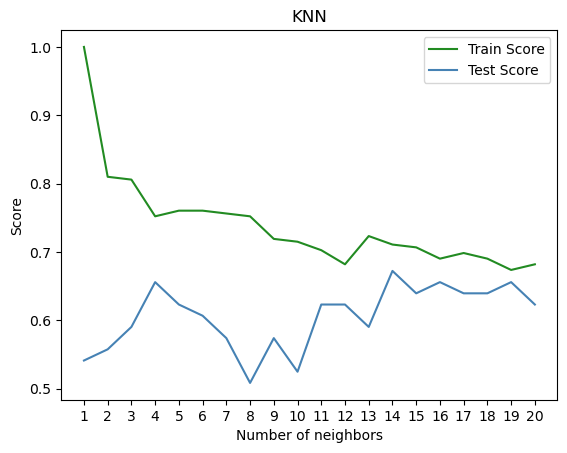

In [37]:
# Plot results
plt.plot(neighbors, train_score, label='Train Score', c= 'forestgreen')
plt.plot(neighbors, test_score , label= 'Test Score', c= 'steelblue')
plt.xticks(np.arange(1,21,1))
plt.xlabel('Number of neighbors')
plt.ylabel('Score')
plt.title('KNN')
plt.legend()

print(f'The maximum accuracy obtained for KNN is {max(test_score)*100:.2f}%')

After the KNN ML model "hyperparameter tunning", the model's score haven't surpass the other model's score. This is the why we will stop with KNN and continue with the other two: **Logistic Regression** and **Random Forest Classifier**.

## Hyperparameter tuning with RandomizedSearchCV

`LogisticRegression()` and `RandomForestClassifier()` hyperparameter tuning were done employing `RandomizedSearchCV()`.

In [42]:
# Logistic Regression Grid
log_reg_grid = {'penalty': ['l1', 'l2'], 
                'solver': ['liblinear'], # good for small datasets
                'C': np.logspace(-2,2,10)}

# Random Forest Classifier Grid
rf_grid = {'n_estimators': np.arange(10,210,10), 
           'max_depth': [None, 3, 5, 10], 
           'min_samples_split': [2,3,5, 10], 
           'min_samples_leaf': [1,2,3], 
           'max_features': ['sqrt', 'log2', None], 
           'class_weight': ['balanced', None]}

### Logistic Regression RandomizedSearchCV

In [43]:
# Initial seed
np.random.seed(28)

# Log Reg RandomizedSearchCV definition
log_reg_rs = RandomizedSearchCV(LogisticRegression(max_iter=1000), 
                                param_distributions=log_reg_grid, 
                                cv = 5, 
                                n_iter= 10,
                                verbose=True)

# Fitting Log Reg Rando....
log_reg_rs.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
                   param_distributions={'C': array([1.00000000e-02, 2.78255940e-02, 7.74263683e-02, 2.15443469e-01,
       5.99484250e-01, 1.66810054e+00, 4.64158883e+00, 1.29154967e+01,
       3.59381366e+01, 1.00000000e+02]),
                                        'penalty': ['l1', 'l2'],
                                        'solver': ['liblinear']},
                   verbose=True)

In [44]:
print(f'The optimal hyperparameter for maximizing accuracy in our Logistic Regression Machine Learning model is \n \
{log_reg_rs.best_params_}')

print(f'Its score is \n {log_reg_rs.score(X_test, y_test)}')

The optimal hyperparameter for maximizing accuracy in our Logistic Regression Machine Learning model is 
 {'solver': 'liblinear', 'penalty': 'l2', 'C': 0.5994842503189409}
Its score is 
 0.8524590163934426


### Random Forest Classifier RandomizedSearchCV

In [45]:
# Initiaze seed
np.random.seed(28)

# Define RandomizedSEarch for RandomForestClassifier ML model 
rf_rs = RandomizedSearchCV(RandomForestClassifier(),
                           param_distributions=rf_grid, 
                           cv = 5, 
                           n_iter=30,
                           verbose=3)

# Fit the above!
rf_rs.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END class_weight=balanced, max_depth=3, max_features=None, min_samples_leaf=2, min_samples_split=2, n_estimators=20;, score=0.816 total time=   0.0s
[CV 2/5] END class_weight=balanced, max_depth=3, max_features=None, min_samples_leaf=2, min_samples_split=2, n_estimators=20;, score=0.878 total time=   0.0s
[CV 3/5] END class_weight=balanced, max_depth=3, max_features=None, min_samples_leaf=2, min_samples_split=2, n_estimators=20;, score=0.854 total time=   0.0s
[CV 4/5] END class_weight=balanced, max_depth=3, max_features=None, min_samples_leaf=2, min_samples_split=2, n_estimators=20;, score=0.708 total time=   0.0s
[CV 5/5] END class_weight=balanced, max_depth=3, max_features=None, min_samples_leaf=2, min_samples_split=2, n_estimators=20;, score=0.833 total time=   0.0s
[CV 1/5] END class_weight=None, max_depth=3, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.816 total time= 

[CV 3/5] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=130;, score=0.812 total time=   0.1s
[CV 4/5] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=130;, score=0.729 total time=   0.1s
[CV 5/5] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=130;, score=0.854 total time=   0.1s
[CV 1/5] END class_weight=None, max_depth=5, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=30;, score=0.796 total time=   0.0s
[CV 2/5] END class_weight=None, max_depth=5, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=30;, score=0.878 total time=   0.0s
[CV 3/5] END class_weight=None, max_depth=5, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=30;, score=0.854 total time=   0.0s
[CV 4/5] END class_weight=None, max_depth=5, m

[CV 1/5] END class_weight=balanced, max_depth=5, max_features=log2, min_samples_leaf=2, min_samples_split=3, n_estimators=90;, score=0.837 total time=   0.0s
[CV 2/5] END class_weight=balanced, max_depth=5, max_features=log2, min_samples_leaf=2, min_samples_split=3, n_estimators=90;, score=0.918 total time=   0.0s
[CV 3/5] END class_weight=balanced, max_depth=5, max_features=log2, min_samples_leaf=2, min_samples_split=3, n_estimators=90;, score=0.854 total time=   0.0s
[CV 4/5] END class_weight=balanced, max_depth=5, max_features=log2, min_samples_leaf=2, min_samples_split=3, n_estimators=90;, score=0.771 total time=   0.0s
[CV 5/5] END class_weight=balanced, max_depth=5, max_features=log2, min_samples_leaf=2, min_samples_split=3, n_estimators=90;, score=0.854 total time=   0.0s
[CV 1/5] END class_weight=None, max_depth=5, max_features=None, min_samples_leaf=3, min_samples_split=10, n_estimators=100;, score=0.816 total time=   0.1s
[CV 2/5] END class_weight=None, max_depth=5, max_featu

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=30,
                   param_distributions={'class_weight': ['balanced', None],
                                        'max_depth': [None, 3, 5, 10],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 3],
                                        'min_samples_split': [2, 3, 5, 10],
                                        'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200])},
                   verbose=3)

In [47]:
print(f'The random forest classifier hyperparameters that best approximates the test results are \n \
      {rf_rs.best_params_}. \n\n Its associated score is \n {rf_rs.score(X_test, y_test)}.')

The random forest classifier hyperparameters that best approximates the test results are 
       {'n_estimators': 80, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}. 

 Its associated score is 
 0.819672131147541.


In [48]:
print(model_scores)

{'Logistic Regression': 0.8524590163934426, 'KNN': 0.6229508196721312, 'Random Forest': 0.819672131147541}


## Logistic Regression GridSearchCV

We extensively evaluate our `LogisticRegression()` model in all the provided points by means of `GridSearchCV()`

In [49]:
# Define grid for GridSearchCV
log_reg_grid = {'C': np.logspace(-4,4,30), 
                'penalty': ['l1', 'l2'], 
                'solver': ['liblinear']}

# Create Logistic Regression Grid seearch function
log_reg_gs = GridSearchCV(LogisticRegression(), 
                          param_grid= log_reg_grid, 
                          cv = 5, 
                          verbose= 3)

# Fit of the Log Reg model with Grid search with the parameters defined
log_reg_gs.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV 1/5] END C=0.0001, penalty=l1, solver=liblinear;, score=0.449 total time=   0.0s
[CV 2/5] END C=0.0001, penalty=l1, solver=liblinear;, score=0.449 total time=   0.0s
[CV 3/5] END C=0.0001, penalty=l1, solver=liblinear;, score=0.438 total time=   0.0s
[CV 4/5] END C=0.0001, penalty=l1, solver=liblinear;, score=0.438 total time=   0.0s
[CV 5/5] END C=0.0001, penalty=l1, solver=liblinear;, score=0.458 total time=   0.0s
[CV 1/5] END C=0.0001, penalty=l2, solver=liblinear;, score=0.592 total time=   0.0s
[CV 2/5] END C=0.0001, penalty=l2, solver=liblinear;, score=0.633 total time=   0.0s
[CV 3/5] END C=0.0001, penalty=l2, solver=liblinear;, score=0.771 total time=   0.0s
[CV 4/5] END C=0.0001, penalty=l2, solver=liblinear;, score=0.604 total time=   0.0s
[CV 5/5] END C=0.0001, penalty=l2, solver=liblinear;, score=0.646 total time=   0.0s
[CV 1/5] END C=0.00018873918221350977, penalty=l1, solver=liblinear;, score=0.449 total 

[CV 4/5] END C=0.05736152510448681, penalty=l2, solver=liblinear;, score=0.792 total time=   0.0s
[CV 5/5] END C=0.05736152510448681, penalty=l2, solver=liblinear;, score=0.792 total time=   0.0s
[CV 1/5] END C=0.1082636733874054, penalty=l1, solver=liblinear;, score=0.796 total time=   0.0s
[CV 2/5] END C=0.1082636733874054, penalty=l1, solver=liblinear;, score=0.837 total time=   0.0s
[CV 3/5] END C=0.1082636733874054, penalty=l1, solver=liblinear;, score=0.854 total time=   0.0s
[CV 4/5] END C=0.1082636733874054, penalty=l1, solver=liblinear;, score=0.729 total time=   0.0s
[CV 5/5] END C=0.1082636733874054, penalty=l1, solver=liblinear;, score=0.750 total time=   0.0s
[CV 1/5] END C=0.1082636733874054, penalty=l2, solver=liblinear;, score=0.816 total time=   0.0s
[CV 2/5] END C=0.1082636733874054, penalty=l2, solver=liblinear;, score=0.878 total time=   0.0s
[CV 3/5] END C=0.1082636733874054, penalty=l2, solver=liblinear;, score=0.854 total time=   0.0s
[CV 4/5] END C=0.10826367338

[CV 2/5] END C=17.433288221999874, penalty=l2, solver=liblinear;, score=0.898 total time=   0.0s
[CV 3/5] END C=17.433288221999874, penalty=l2, solver=liblinear;, score=0.792 total time=   0.0s
[CV 4/5] END C=17.433288221999874, penalty=l2, solver=liblinear;, score=0.771 total time=   0.0s
[CV 5/5] END C=17.433288221999874, penalty=l2, solver=liblinear;, score=0.854 total time=   0.0s
[CV 1/5] END C=32.90344562312671, penalty=l1, solver=liblinear;, score=0.796 total time=   0.0s
[CV 2/5] END C=32.90344562312671, penalty=l1, solver=liblinear;, score=0.898 total time=   0.0s
[CV 3/5] END C=32.90344562312671, penalty=l1, solver=liblinear;, score=0.792 total time=   0.0s
[CV 4/5] END C=32.90344562312671, penalty=l1, solver=liblinear;, score=0.771 total time=   0.0s
[CV 5/5] END C=32.90344562312671, penalty=l1, solver=liblinear;, score=0.854 total time=   0.0s
[CV 1/5] END C=32.90344562312671, penalty=l2, solver=liblinear;, score=0.796 total time=   0.0s
[CV 2/5] END C=32.90344562312671, pe

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': array([1.00000000e-04, 1.88739182e-04, 3.56224789e-04, 6.72335754e-04,
       1.26896100e-03, 2.39502662e-03, 4.52035366e-03, 8.53167852e-03,
       1.61026203e-02, 3.03919538e-02, 5.73615251e-02, 1.08263673e-01,
       2.04335972e-01, 3.85662042e-01, 7.27895384e-01, 1.37382380e+00,
       2.59294380e+00, 4.89390092e+00, 9.23670857e+00, 1.74332882e+01,
       3.29034456e+01, 6.21016942e+01, 1.17210230e+02, 2.21221629e+02,
       4.17531894e+02, 7.88046282e+02, 1.48735211e+03, 2.80721620e+03,
       5.29831691e+03, 1.00000000e+04]),
                         'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
             verbose=3)

In [50]:
print(f'The parameters that maxizime the ML model\'s score is {log_reg_gs.best_params_}.\n\n \
The associated score for the test data using these hyperparameters is {log_reg_gs.score(X_test, y_test)}.')

The parameters that maxizime the ML model's score is {'C': 0.20433597178569418, 'penalty': 'l2', 'solver': 'liblinear'}.

 The associated score for the test data using these hyperparameters is 0.8524590163934426.


## Machine Learning Classifier Evaluation beyond Accuracy 

* ROC Curve and AUC score
* Confusion Matrix
* Classification Report
* Precision
* Recall
* F1-score

### ROC Curve and Area Under the Curve (AUC)

In [51]:
y_preds = log_reg_gs.predict(X_test)

In [52]:
print(f'The predicted values are {y_preds} \n\n The true values are {y_test}')

The predicted values are [1 1 1 1 0 1 1 0 0 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 0 0 1 1
 1 1 0 0 1 0 1 1 1 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0] 

 The true values are 86     1
33     1
228    0
155    1
203    0
      ..
187    0
238    0
248    0
58     1
207    0
Name: target, Length: 61, dtype: int64


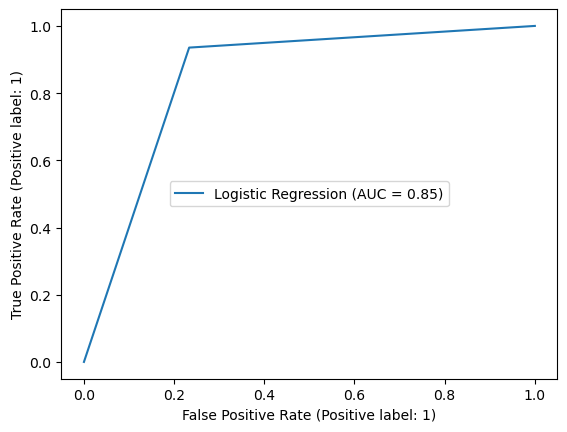

In [59]:
# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_preds, name= 'Logistic Regression').ax_.legend(loc= 'center')

plt.show()

### Confusion Matrix

In [60]:
# Define Confusion matrix
confusion_matrix(y_test, y_preds)

array([[23,  7],
       [ 2, 29]], dtype=int64)

In [62]:
sns.set(font_scale=1.5) # Increase font size

# Create function for a nice confusion matrix display
def plot_conf_mat(y_test, y_preds):
    """
    Plots a confusion matrix using Seaborn's heatmap().
    """
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     cmap = "PiYG",
                     annot=True, # Annotate the number in the boxes
                     cbar=False)
    plt.xlabel("Predicted label") # predictions go on the x-axis
    plt.ylabel("True label")
    plt.yticks(rotation = 0)

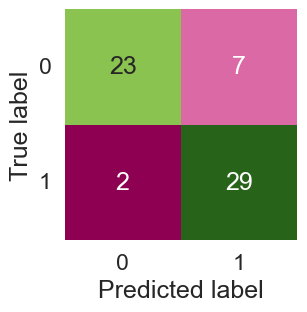

In [63]:
plot_conf_mat(y_test, y_preds)

From the confusion matrix, we can divide information into 4 cases:
* True Negatives: 23
* True Positives: 29
* False Positives: 7
* False Negatives: 2

Special attention must be given to the false negatives. In this case (in the medical field), it is of utmost importance to minimize (and ideally to reduce it to zero) the number of false negatives. 

### Classification Report
(We should include some sort of Cross-validation. Why? Because we are only testing in a small percentage of the total data
A more accurate assessment is done by the evaluation of each patient by means of the Cross Validation)

In [64]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.92      0.77      0.84        30
           1       0.81      0.94      0.87        31

    accuracy                           0.85        61
   macro avg       0.86      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61



## Classification Report with Cross validation

In [77]:
# Create dictionary 
cv_scores = {'accuracy': [],
             'precision': [],
             'recall': [], 
             'f1': []}

In [78]:
# Get the best parameters for our ML model classifier
print(log_reg_gs.best_params_)

{'C': 0.20433597178569418, 'penalty': 'l2', 'solver': 'liblinear'}


In [79]:
# Define the ML model classifier with the "optimal" hyperparameters
clf = LogisticRegression(C = log_reg_gs.best_params_['C'],
                         penalty = log_reg_gs.best_params_['penalty'],
                         solver = log_reg_gs.best_params_['solver'])



# Loop through the different score "methods"
for score in cv_scores.keys():
    score_value = cross_val_score(clf, X, y, scoring=score, cv=5)
    score_value_avg = np.mean(score_value) # Averaging over the five score obtained (because we selected cv= 5)
    cv_scores[score].append(score_value_avg)
    
print(cv_scores)

{'accuracy': [0.8446994535519124], 'precision': [0.8207936507936507], 'recall': [0.9212121212121213], 'f1': [0.8673007976269721]}


Text(0, 0.5, 'Score')

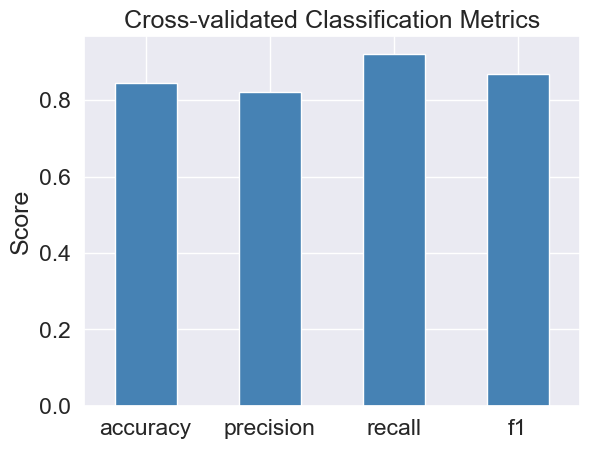

In [80]:
## For better visualization we use a DataFrame and plot it in a bar plot

cv_metrics = pd.DataFrame(cv_scores, index=[0])

# PLOT!
cv_metrics.T.plot.bar(title='Cross-validated Classification Metrics', color= 'steelblue', legend= False)
plt.xticks(rotation = 0)
plt.ylabel('Score')

## Feature Importance 

An interesting question we may ask ourselves is: Which feature(s) do play a role with the prediction in our model? Some features could have more influence or importance. Some of them may not affect the outcome too much (at least for our model). 

In [81]:
# Define the ML model classifier with the "optimal" hyperparameters
clf = LogisticRegression(C = log_reg_gs.best_params_['C'],
                         penalty = log_reg_gs.best_params_['penalty'],
                         solver = log_reg_gs.best_params_['solver'])

# Fit data
clf.fit(X_train, y_train)

# coef_ attribute returns the feature importance of each one of them
print(clf.coef_)

[[-0.00496178 -0.74687716  0.68677072 -0.00647658 -0.00239307 -0.07351032
   0.23336312  0.02466408 -0.44854608 -0.57180704  0.35938501 -0.61663044
  -0.58411474]]


Let's make it more visual

In [82]:
feature_dict = dict(zip(df.columns,list(clf.coef_[0])))
print(feature_dict)

{'age': -0.004961779313729438, 'sex': -0.7468771595527895, 'cp': 0.6867707162172827, 'trestbps': -0.006476580495175919, 'chol': -0.00239307367669003, 'fbs': -0.07351032185029355, 'restecg': 0.233363115255095, 'thalach': 0.024664078405840263, 'exang': -0.4485460790944044, 'oldpeak': -0.5718070367358122, 'slope': 0.35938501383972277, 'ca': -0.6166304374448675, 'thal': -0.5841147430900195}


<Axes: title={'center': 'ML model Feature Importance'}>

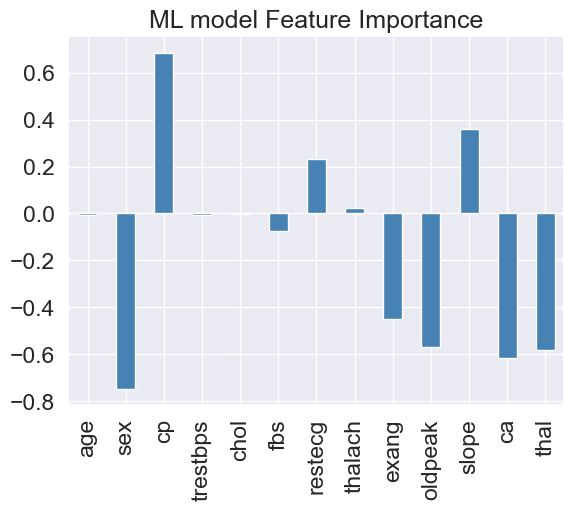

In [83]:
# Feature importance DataFrame for plot
feature_df = pd.DataFrame(feature_dict, index = [0])

# Bar plot
feature_df.T.plot.bar(title= 'ML model Feature Importance', color= 'steelblue', legend = False)

In [84]:
pd.crosstab(df['sex'], df['target'])

target,0,1
sex,,
0,24,72
1,114,93


In [85]:
pd.crosstab(df['slope'], df['target'])

target,0,1
slope,,
0,12,9
1,91,49
2,35,107


For example, *slope* refers to the slope of the peak exercise ST segment. For value: 
* 0: Upsloping
* 1: Flat
* 2: Downsloping

From here we can have some insight of the variable on predicting heart disease. 

# 6. Next steps
 
The goal is to hit a 95% of metric evaluation. We can further improve our model by: 

* Could we get more data from the clinic/hospital?
* Could we try other ML model classifiers? 
* Could we apply an in-depth hyperparameter tuning? 
* Discuss with experts on the field